In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

In [85]:
# Converting the csv into a dataframe

df = pd.read_csv(".\\heart_disease_uci.csv")

In [86]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [88]:
# Checking for missing values

df["age"].isna().sum()

np.int64(0)

In [89]:
df['age'].dtype

dtype('int64')

In [90]:
# Checking if there are any irregular values

df['age'].unique()

array([63, 67, 37, 41, 56, 62, 57, 53, 44, 52, 48, 54, 49, 64, 58, 60, 50,
       66, 43, 40, 69, 59, 42, 55, 61, 65, 71, 51, 46, 45, 39, 68, 47, 34,
       35, 29, 70, 77, 38, 74, 76, 28, 30, 31, 32, 33, 36, 72, 73, 75])

In [91]:
df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [92]:
df['sex'].isnull().sum()

np.int64(0)

In [93]:
df['sex'].dtype

dtype('O')

In [94]:
df['sex'].value_counts().sum()

np.int64(920)

In [95]:
df['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [96]:
df['dataset'].value_counts().sum()

np.int64(920)

In [97]:
df['dataset'].isna().sum()

np.int64(0)

In [98]:
df['cp'].unique()

array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object)

In [99]:
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

In [100]:
df['cp'].value_counts().sum()

np.int64(920)

In [101]:
df['cp'].isna().sum()

np.int64(0)

In [102]:
df['trestbps'].isna().sum()

np.int64(59)

In [103]:
df['trestbps'].min()

0.0

In [104]:
df['trestbps'].max()

200.0

In [105]:
df['trestbps'].unique()

array([145., 160., 120., 130., 140., 172., 150., 110., 132., 117., 135.,
       112., 105., 124., 125., 142., 128., 170., 155., 104., 180., 138.,
       108., 134., 122., 115., 118., 100., 200.,  94., 165., 102., 152.,
       101., 126., 174., 148., 178., 158., 192., 129., 144., 123., 136.,
       146., 106., 156., 154., 114., 164.,  98., 190.,  nan, 113.,  92.,
        95.,  80., 185., 116.,   0.,  96., 127.])

In [106]:
# Checking for 0 values as 0 blood pressure is impossible and i see 0 in unique

(df['trestbps'] == 0).sum()

np.int64(1)

In [107]:
df['trestbps'] = df['trestbps'].replace(0, np.nan)

In [108]:
# Calculate the percentage of missing values in the 'trestbps' column

(df['trestbps'].isna().sum() / len(df)) * 100

np.float64(6.521739130434782)

In [109]:
# Only 6% of data is missing. We can use any kind of imputer.
imputer = SimpleImputer(strategy='median')

df['trestbps'] = imputer.fit_transform(df[['trestbps']])

In [110]:
df['trestbps'].isna().sum()

np.int64(0)

<Axes: xlabel='trestbps', ylabel='Count'>

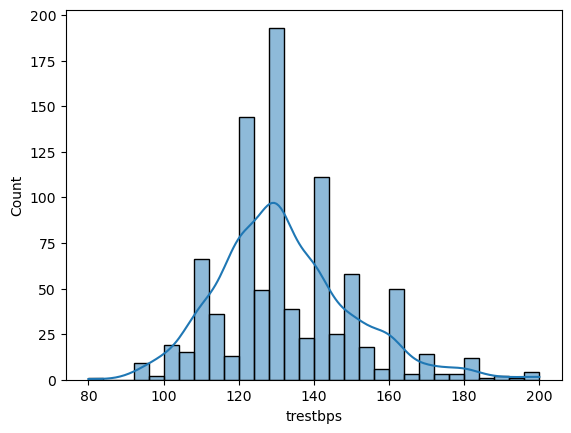

In [111]:
# Checking the distribution of the column

sns.histplot(df['trestbps'], kde=True)

In [112]:
df['trestbps'].value_counts().sort_values(ascending=False).head(10)

trestbps
130.0    175
120.0    131
140.0    102
110.0     59
150.0     56
160.0     50
125.0     29
115.0     19
135.0     18
128.0     17
Name: count, dtype: int64

In [113]:
df['chol'].isna().sum()

np.int64(30)

<Axes: xlabel='chol', ylabel='Count'>

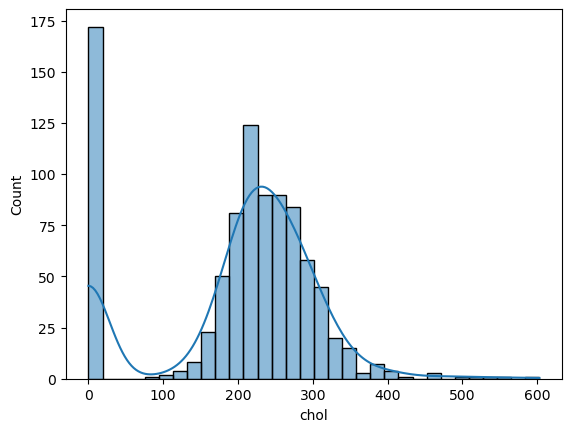

In [114]:
# Checking the distribution of the column

sns.histplot(df['chol'], kde=True)

In [115]:
# Same logic as before, 0 cholestrol is not possible

(df['chol'] == 0).sum()

np.int64(172)

In [116]:
df['chol'] = df['chol'].replace(0, np.nan)

In [117]:
df['chol'].isna().sum()

np.int64(202)

In [118]:
# IMPUTING WITH ITERATIVE IMPUTER
chol_imputer = IterativeImputer(random_state=42, max_iter=10)

df['chol'] = chol_imputer.fit_transform(df[['chol']])

<Axes: xlabel='chol', ylabel='Count'>

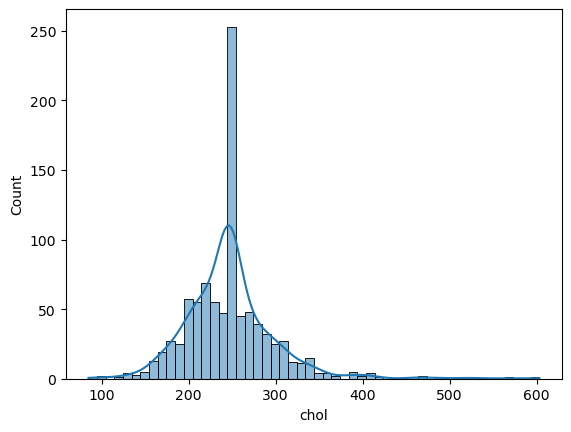

In [119]:
# Checking the distribution of the column

sns.histplot(df['chol'], kde=True)

In [120]:
df['fbs'].unique()

array([True, False, nan], dtype=object)

In [121]:
df['fbs'].value_counts().unique()

array([692, 138])

In [122]:
df['fbs'].isna().sum()

np.int64(90)

In [123]:
# IMPUTING MISSING VALUES
fbs_imputer = SimpleImputer(strategy="median")

df['fbs'] = fbs_imputer.fit_transform(df[['fbs']])

In [124]:
df['fbs'].isna().sum()

np.int64(0)

In [125]:
df['restecg'].isna().sum()

np.int64(2)

In [126]:
df['restecg'].value_counts()

restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

In [127]:
# IMPUTE MISSING VALUES
restecg_imputer = SimpleImputer(strategy='most_frequent')

df[['restecg']] = restecg_imputer.fit_transform(df[['restecg']])

In [128]:
df['restecg'].isna().sum()

np.int64(0)

In [129]:
df['thalch'].isna().sum()

np.int64(55)

<Axes: xlabel='thalch', ylabel='Count'>

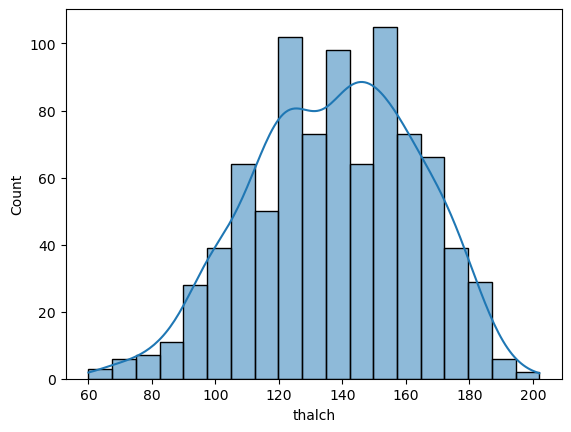

In [130]:
# Checking the distribution of the column

sns.histplot(df['thalch'], kde=True)

In [131]:
# IMPUTE MISSING VALUES
thalch_imputer = SimpleImputer(strategy='mean')

df['thalch'] = thalch_imputer.fit_transform(df[['thalch']])

In [132]:
df['thalch'].isna().sum()

np.int64(0)

In [133]:
df['exang'].isna().sum()

np.int64(55)

In [134]:
df['exang'].unique()

array([False, True, nan], dtype=object)

In [135]:
# IMPUTE MISSING VALUES
exang_imputer = SimpleImputer(strategy='most_frequent')

df[['exang']] = exang_imputer.fit_transform(df[['exang']])

In [136]:
df['exang'].unique()

array([False, True], dtype=object)

In [137]:
df['oldpeak'].isna().sum()

np.int64(62)

<Axes: xlabel='oldpeak', ylabel='Count'>

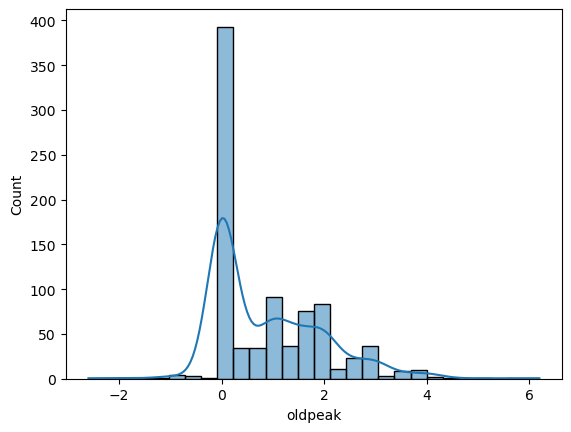

In [138]:
# Checking the distribution of the column

sns.histplot(df['oldpeak'], kde=True)

In [139]:
df['oldpeak'].value_counts()

oldpeak
 0.0    370
 1.0     83
 2.0     76
 1.5     48
 3.0     28
 0.5     19
 1.2     17
 2.5     16
 1.4     15
 0.8     15
 1.6     14
 0.2     14
 0.6     14
 1.8     12
 0.4     10
 0.1      9
 4.0      8
 2.6      7
 2.8      7
 1.3      5
 2.2      5
 0.7      5
 1.9      5
 0.3      5
 3.6      4
 2.4      4
 1.1      4
 0.9      4
 3.4      3
 1.7      2
-1.0      2
 4.2      2
 2.3      2
 2.1      2
-0.5      2
 3.2      2
 3.5      2
-0.8      1
-0.1      1
-0.9      1
-2.0      1
-0.7      1
-2.6      1
 6.2      1
-1.5      1
-1.1      1
 5.0      1
 4.4      1
 3.8      1
 2.9      1
 5.6      1
 3.1      1
 3.7      1
Name: count, dtype: int64

In [140]:
df['oldpeak'].isna().sum()

np.int64(62)

In [141]:
# REMOVING NEGATIVE VALUES
df.loc[df['oldpeak'] < 0, 'oldpeak'] = np.nan

# IMPUTE MISSING VALUES AGAIN
oldpeak_imputer = SimpleImputer(strategy='median')

df['oldpeak'] = oldpeak_imputer.fit_transform(df[['oldpeak']])

In [142]:
df['slope'].unique()

array(['downsloping', 'flat', 'upsloping', nan], dtype=object)

In [143]:
df['slope'].isna().sum()

np.int64(309)

In [144]:
# DROPPING IT. TOO MUCH MISSING VALUES.

df.drop('slope', axis=1, inplace=True)

In [145]:
df['ca'].unique()

array([ 0.,  3.,  2.,  1., nan])

In [146]:
df['ca'].isna().sum()

np.int64(611)

In [147]:
df['ca'].isnull().mean() * 100

np.float64(66.41304347826087)

In [148]:
# SINCE IT HAS MORE THAN 60% NULL VALUES. BETTER OPTION IS TO DROP IT.

df.drop('ca', axis=1, inplace=True)

In [149]:
df['thal'].unique()

array(['fixed defect', 'normal', 'reversable defect', nan], dtype=object)

In [150]:
df['thal'].isna().sum()

np.int64(486)

In [151]:
df['thal'].isnull().mean() * 100

np.float64(52.826086956521735)

In [152]:
# SIMILAR TO PREVIOUS ONE. MORE THAN 50% NULL VALUES. DROPPING IT.

df.drop('thal', axis=1, inplace=True)

In [153]:
# OUR TARGET VARIABLE
df['num'].isna().sum()

np.int64(0)

In [154]:
# DATA ENCODING

In [155]:
# ONE HOT ENCODING / GET DUMMIES FOR 'dataset' and 'cp' column
df = pd.get_dummies(df, columns=['dataset'], drop_first=True)

df = pd.get_dummies(df, columns=['cp'], drop_first=True)

df = pd.get_dummies(df, columns=['restecg'], drop_first=True)

In [156]:
# LABEL ENCODING COLUMNS

sex_encoder = LabelEncoder()
df['sex'] = sex_encoder.fit_transform(df['sex'])

fbs_encoder = LabelEncoder()
df['fbs'] = fbs_encoder.fit_transform(df['fbs'])

exang_encoder = LabelEncoder()
df['exang'] = exang_encoder.fit_transform(df['exang'])

In [157]:
df.drop('id', axis=1, inplace=True)

In [158]:
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,63,1,145.0,233.0,1,150.0,0,2.3,0,False,False,False,False,False,True,False,False
1,67,1,160.0,286.0,0,108.0,1,1.5,2,False,False,False,False,False,False,False,False
2,67,1,120.0,229.0,0,129.0,1,2.6,1,False,False,False,False,False,False,False,False
3,37,1,130.0,250.0,0,187.0,0,3.5,0,False,False,False,False,True,False,True,False
4,41,0,130.0,204.0,0,172.0,0,1.4,0,False,False,False,True,False,False,False,False


In [159]:
print(df['num'].value_counts())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [160]:
X = df.drop('num', axis=1)
y = df['num']

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [79]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5597826086956522
              precision    recall  f1-score   support

           0       0.65      0.89      0.75        75
           1       0.50      0.46      0.48        54
           2       0.39      0.28      0.33        25
           3       0.31      0.15      0.21        26
           4       0.00      0.00      0.00         4

    accuracy                           0.56       184
   macro avg       0.37      0.36      0.35       184
weighted avg       0.51      0.56      0.52       184

[[67  6  2  0  0]
 [21 25  6  2  0]
 [ 3  9  7  6  0]
 [11  9  2  4  0]
 [ 1  1  1  1  0]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [80]:
%%time
# Define the model
model = RandomForestClassifier()

# Create the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    # 'max_features': ['auto', 'sqrt', 'log2'],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 10],
    'criterion': ['gini', 'entropy']
}

# The parameter grid makes combinations using something called a 
# grid search, which basically tries every possible combination
# of the values you gave.

# GridSearchCV

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit the model
grid.fit(X_train, y_train)

# Print the best parameters
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'max_features': 'log2', 'n_estimators': 100}
Best CV Accuracy: 0.6073542930685788
CPU times: total: 1 s
Wall time: 23.4 s


In [83]:
%%time
# Train the xgboost
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Predict test data
y_pred = xgb.predict(X_test)

# Metrics
print('Accuracy Score: ', accuracy_score(y_test, y_pred))
print('Precision Score: ', precision_score(y_test, y_pred, average='micro'))
print('Recall Score: ', recall_score(y_test, y_pred, average='micro'))
print('F1 Score: ', f1_score(y_test, y_pred, average='micro'))

Accuracy Score:  0.5815217391304348
Precision Score:  0.5815217391304348
Recall Score:  0.5815217391304348
F1 Score:  0.5815217391304348
CPU times: total: 2.38 s
Wall time: 272 ms


In [167]:
%%time
# Define the model
model = XGBClassifier()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Print the best parameters
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Accuracy: 0.6046240117668689
CPU times: total: 2.61 s
Wall time: 19.5 s


In [168]:
best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.5597826086956522
              precision    recall  f1-score   support

           0       0.66      0.89      0.76        75
           1       0.55      0.52      0.53        54
           2       0.38      0.24      0.29        25
           3       0.17      0.08      0.11        26
           4       0.00      0.00      0.00         4

    accuracy                           0.56       184
   macro avg       0.35      0.35      0.34       184
weighted avg       0.50      0.56      0.52       184

[[67  4  3  1  0]
 [21 28  3  2  0]
 [ 4  9  6  4  2]
 [10 10  3  2  1]
 [ 0  0  1  3  0]]
